In [ ]:
# Colab Setup: Install required packages
!pip install -q geemap rasterio python-dotenv


In [ ]:
# Colab Setup: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# IMPORTANT: Change this path to where your Project_v2 folder is located in your Google Drive
import os
project_path = '/content/drive/MyDrive/Semester Projects/2nd Semester Project/Satellite Imagery/Project'
os.chdir(project_path)
print('Current working directory:', os.getcwd())

# Upload locations.csv if it doesn't exist in the project path
if not os.path.exists('locations.csv'):
    print('locations.csv not found in ' + os.getcwd() + '. Please upload it:')
    from google.colab import files
    files.upload()
else:
    print('locations.csv found.')


In [ ]:
# Colab Setup: Authenticate Google Earth Engine
import ee
import os

# You can set your Project ID here or as a Colab Secret named 'EE_PROJECT_ID'
PROJECT_ID = "" 

def initialize_ee(project=None):
    try:
        ee.Initialize(project=project)
        print(f"Successfully initialized Earth Engine with project: {project or 'default'}")
    except Exception as e:
        print(f"Initialization failed: {e}")
        print("Attempting to authenticate...")
        ee.Authenticate()
        # If still no project, ask for it
        if not project:
            project = input("Enter your Google Cloud Project ID: ")
        ee.Initialize(project=project)
        print(f"Successfully initialized Earth Engine with project: {project}")

# Try to get project ID from environment or common locations
project_id = PROJECT_ID or os.getenv('EE_PROJECT_ID')
initialize_ee(project_id)


# Imports, Constants, and Shared Setup

In [6]:
from pathlib import Path
import argparse
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import ee
import geemap
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio
from dotenv import load_dotenv

%matplotlib inline
from matplotlib.colors import ListedColormap
from scipy.ndimage import maximum_filter, minimum_filter, uniform_filter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# Always resolve ROOT as the project root regardless of where Jupyter was launched from
ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path().resolve()
# If the notebook is in a 'notebooks/' subfolder, step up one level
if (ROOT / "notebooks").exists() is False and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
elif (ROOT / "locations.csv").exists() is False and (ROOT.parent / "locations.csv").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "samples_generated"

MODEL_DIR = ROOT / "outputs" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {1: "Greenery", 2: "Sand", 3: "Water", 4: "Cement"}
CLASS_IDS = list(CLASS_NAMES)
TARGET_NAMES = [CLASS_NAMES[class_id] for class_id in CLASS_IDS]

COLORS = np.array([
    [0, 0, 0],
    [0, 100, 0],
    [184, 134, 11],
    [0, 0, 139],
    [105, 105, 105],
], dtype=np.uint8)

RANDOM_STATE = 42
TARGET_SAMPLE = "AlKhargaOasis"

def clean_mask(mask, edge_size=3):
    clean = mask.copy()
    noisy_edge = maximum_filter(clean, size=edge_size) != minimum_filter(clean, size=edge_size)
    clean[(~np.isin(clean, CLASS_IDS)) | noisy_edge] = 0
    return clean

def scale_input(spectral):
    return np.clip(spectral / 10000.0, 0, 1)

def rgb_preview(spectral):

    rgb = np.moveaxis(spectral[[3, 2, 1]], 0, -1)
    low = np.percentile(rgb, 2, axis=(0, 1), keepdims=True)
    high = np.percentile(rgb, 98, axis=(0, 1), keepdims=True)

    return np.clip((rgb - low) / (high - low + 1e-6), 0, 1)

def colorize(mask):
    return COLORS[mask]

def load_samples():
    records = []
    for spectral_path in sorted(DATA_DIR.glob("*/*_Spectral.tif")):
        sample = spectral_path.parent.name
        mask_path = spectral_path.with_name(f"{sample}_Mask.tif")
        if mask_path.exists():
            records.append({
                "sample": sample,
                "spectral_path": spectral_path,
                "mask_path": mask_path,
            })
    return pd.DataFrame.from_records(records)

samples = load_samples()


# Data Acquisition

In [7]:
# Data Acquisition Settings
DEFAULT_CSV = ROOT / "locations.csv"
OUT_DIR = ROOT / "data" / "samples_generated"

START_DATE = "2025-05-01"
END_DATE = "2025-08-28"
BUFFER_M = 1280
MAX_CLOUD = 20
SCALE = 10
MIN_LABEL_CONFIDENCE = 0.45

S2_BANDS = [
    "B1", "B2", "B3", "B4", "B5", "B6",
    "B7", "B8", "B8A", "B9", "B11", "B12",
]

CLASS_PROB_BANDS = {
    "greenery": ["trees", "grass", "flooded_vegetation", "crops"],
    "sand": ["bare"],
    "water": ["water"],
    "cement": ["built"],
}

DW_PROB_BANDS = [band for bands in CLASS_PROB_BANDS.values() for band in bands]

NAME_ALIASES = {
    "Cairo University": "CairoUniv",
    "Iconic Tower, New Administrative Capital": "IconicTower",
}

def sample_name(name):
    if name in NAME_ALIASES:
        return NAME_ALIASES[name]

    words = "".join(c if c.isalnum() else " " for c in name).split()
    return "".join(word[:1].upper() + word[1:] for word in words)

def init_ee():
    # Earth Engine is already initialized in the Colab Setup cell above
    pass






def mask_clouds(image):
    scl = image.select("SCL")
    clear = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
    return image.updateMask(clear)

def sentinel2(region, start, end, max_cloud):
    return (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(region)
        .filterDate(start, end)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", max_cloud))
        .map(mask_clouds)
    )

def dynamic_world(region, start, end):
    return ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1").filterBounds(region).filterDate(start, end)

def confident_mask(dw, region):
    probs = dw.select(DW_PROB_BANDS).mean().clip(region)
    scores = ee.Image.cat(*[
        probs.select(bands).reduce(ee.Reducer.sum()).rename(name)
        for name, bands in CLASS_PROB_BANDS.items()
    ])

    best_score = scores.reduce(ee.Reducer.max())
    mask = scores.toArray().arrayArgmax().arrayGet([0]).add(1).rename("macro_class")
    return mask.where(best_score.lt(MIN_LABEL_CONFIDENCE), 0).toUint8()

def build_image(region, start, end, max_cloud):
    s2 = sentinel2(region, start, end, max_cloud)
    dw = dynamic_world(region, start, end)

    spectral = s2.select(S2_BANDS).median().clip(region)
    image = spectral.addBands(confident_mask(dw, region))
    return image, s2.size().getInfo(), dw.size().getInfo()


def export_image(image, path, region):
    geemap.ee_export_image(
        image,
        str(path),
        crs="EPSG:4326",
        region=region,
        scale=SCALE,
        file_per_band=False,
        verbose=False,
    )
    if not path.exists():
        raise RuntimeError(f"export failed: {path.name} was not created")


def split_stack(stack_path, spectral_path, mask_path):
    with rio.open(stack_path) as src:
        data = src.read()
        profile = src.profile

    if data.shape[0] != len(S2_BANDS) + 1:
        raise RuntimeError(f"expected {len(S2_BANDS) + 1} bands, found {data.shape[0]}")

    spectral_profile = {**profile, "count": len(S2_BANDS), "dtype": "float64", "nodata": None}
    mask_profile = {**profile, "count": 1, "dtype": "uint8", "nodata": 0}

    with rio.open(spectral_path, "w", **spectral_profile) as dst:
        dst.write(data[:len(S2_BANDS)].astype("float64"))

    with rio.open(mask_path, "w", **mask_profile) as dst:
        dst.write(data[len(S2_BANDS):].astype("uint8"))

    stack_path.unlink(missing_ok=True)

def save_preview(spectral_path, mask_path, preview_path):
    with rio.open(spectral_path) as src:
        rgb = np.moveaxis(src.read([4, 3, 2]).astype("float32"), 0, -1)
        
    low = np.percentile(rgb, 2, axis=(0, 1), keepdims=True)
    high = np.percentile(rgb, 98, axis=(0, 1), keepdims=True)
    rgb = np.clip((rgb - low) / (high - low + 1e-6), 0, 1)

    with rio.open(mask_path) as src:
        mask = src.read(1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(rgb)
    axes[0].set_title("RGB")
    axes[1].imshow(mask, cmap=ListedColormap(COLORS/255.0), vmin=0, vmax=4, interpolation="nearest")
    axes[1].set_title("Mask")

    for ax in axes:
        ax.axis("off")

    fig.tight_layout()
    fig.savefig(preview_path, dpi=122, facecolor="white")
    plt.close(fig)

def download_location(row, start, end, buffer_m, max_cloud):
    name = sample_name(row.name)
    folder = OUT_DIR / name
    folder.mkdir(parents=True, exist_ok=True)

    spectral_path = folder / f"{name}_Spectral.tif"
    mask_path = folder / f"{name}_Mask.tif"
    preview_path = folder / f"{name}_viz.png"
    stack_path = folder / f".{name}_stack.tif"

    point = ee.Geometry.Point([row.longitude, row.latitude])
    region = point.buffer(buffer_m).bounds()
    image, s2_count, dw_count = build_image(region, start, end, max_cloud)

    if not s2_count:
        print(f"skip {name}: no Sentinel-2 images")
        return "no_s2"
    if not dw_count:
        print(f"skip {name}: no Dynamic World images")
        return "no_dw"

    export_image(image, stack_path, region)
    split_stack(stack_path, spectral_path, mask_path)
    save_preview(spectral_path, mask_path, preview_path)
    print(f"saved {name}")
    return "saved"

class Args:
    csv = DEFAULT_CSV
    start = START_DATE
    end = END_DATE
    buffer = BUFFER_M
    max_cloud = MAX_CLOUD
    only = None

def parse_args():
    return Args()


In [8]:
args = parse_args()
init_ee()

if args.csv.exists():
    rows = pd.read_csv(args.csv)
    if args.only:
        rows = rows[rows["name"].isin(args.only)]
    
    locations = list(rows.itertuples(index=False))
    iterator = locations if len(locations) == 1 else tqdm(locations, desc="Locations", unit="loc")
    stats = {"saved": 0, "skipped": 0, "no_s2": 0, "no_dw": 0}
    
    for row in iterator:
        name = sample_name(row.name)
        folder = OUT_DIR / name
        spectral_path = folder / f"{name}_Spectral.tif"
        mask_path = folder / f"{name}_Mask.tif"

        if spectral_path.exists() and mask_path.exists():
            stats["skipped"] += 1
            continue  # skip

        status = download_location(row, args.start, args.end, args.buffer, args.max_cloud)
        stats[status] += 1
    print(stats)
else:
    print("locations.csv not found, skipping download.")


Locations:   0%|          | 0/100 [00:00<?, ?loc/s]

{'saved': 0, 'skipped': 100, 'no_s2': 0, 'no_dw': 0}


# Random Forest Baseline

In [9]:
MAX_PIXELS_PER_CLASS = 1500

RF_PARAMS = {
    "n_estimators": 120,
    "max_depth": 24,
    "min_samples_leaf": 2,
    "class_weight": "balanced_subsample",
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
}

def load_sample_rf(row):
    with rio.open(row.spectral_path) as src:
        spectral = scale_input(src.read().astype("float32"))
    with rio.open(row.mask_path) as src:
        mask = clean_mask(src.read(1).astype("uint8"))
    return spectral, mask

def norm_diff(a, b):
    return (a - b) / (a + b + 1e-6)

def local_stats(image, size=5):
    mean = uniform_filter(image, size=size, mode="nearest")
    sq_mean = uniform_filter(image * image, size=size, mode="nearest")
    std = np.sqrt(np.clip(sq_mean - mean * mean, 0, None))
    return mean, std

def add_features(spectral):
    bands = np.moveaxis(spectral, 0, -1)
    b2, b3, b4 = bands[..., 1], bands[..., 2], bands[..., 3]
    b8, b11 = bands[..., 7], bands[..., 10]

    ndvi = norm_diff(b8, b4)
    ndwi = norm_diff(b3, b8)
    mndwi = norm_diff(b3, b11)
    ndbi = norm_diff(b11, b8)

    bsi = ((b11 + b4) - (b8 + b2)) / ((b11 + b4) + (b8 + b2) + 1e-6)

    features = [
        bands,
        ndvi[..., None],
        ndwi[..., None],
        mndwi[..., None],
        ndbi[..., None],
        bsi[..., None],
    ]

    for layer in [ndvi, mndwi, ndbi, b11]:
        mean, std = local_stats(layer)
        features.extend([mean[..., None], std[..., None]])

    return np.dstack(features).astype("float32")

def predict_scene_rf(model, spectral):
    features = add_features(spectral)
    height, width, feature_count = features.shape
    pred = model.predict(features.reshape(-1, feature_count))
    
    return pred.reshape(height, width).astype("uint8")

def build_training_set(frame, max_per_class_per_image=MAX_PIXELS_PER_CLASS):
    rng = np.random.default_rng(RANDOM_STATE)
    xs, ys = [], []

    for row in frame.itertuples(index=False):
        spectral, mask = load_sample_rf(row)
        features = add_features(spectral)
        flat_features = features.reshape(-1, features.shape[-1])
        labels = mask.reshape(-1)

        for class_id in CLASS_IDS:
            class_pixels = np.flatnonzero(labels == class_id)
            if len(class_pixels) == 0:
                continue

            take = min(max_per_class_per_image, len(class_pixels))
            picked_pixels = rng.choice(class_pixels, size=take, replace=False)

            xs.append(flat_features[picked_pixels])
            ys.append(np.full(take, class_id, dtype=np.uint8))

    return np.vstack(xs), np.concatenate(ys)

def evaluate_model_rf(model, frame):
    cm = np.zeros((len(CLASS_IDS), len(CLASS_IDS)), dtype=np.int64)
    y_true, y_pred = [], []

    for row in frame.itertuples(index=False):
        spectral, mask = load_sample_rf(row)
        pred = predict_scene_rf(model, spectral)
        valid = mask > 0

        cm += confusion_matrix(mask[valid], pred[valid], labels=CLASS_IDS)
        y_true.append(mask[valid].reshape(-1))
        y_pred.append(pred[valid].reshape(-1))

    intersection = np.diag(cm)
    union = cm.sum(axis=1) + cm.sum(axis=0) - intersection
    iou = intersection / np.maximum(union, 1)

    metrics = pd.DataFrame({
        "class_id": CLASS_IDS,
        "class_name": TARGET_NAMES,
        "IoU": iou,
        "support": cm.sum(axis=1),
    })

    report = classification_report(
        np.concatenate(y_true),
        np.concatenate(y_pred),
        labels=CLASS_IDS,
        target_names=TARGET_NAMES,
        zero_division=0,
    )

    return metrics, report


In [10]:
samples = load_samples()
assert len(samples) > 0, (
    f"No samples found in {DATA_DIR}. "
    "Run the Data Acquisition cell first, or check that ROOT points to the project root."
)
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(samples, groups=samples["sample"]))

train_df = samples.iloc[train_idx].reset_index(drop=True)
test_df = samples.iloc[test_idx].reset_index(drop=True)

print(f"train scenes: {len(train_df)}")
print(train_df["sample"].tolist())
print()
print(f"test scenes: {len(test_df)}")
print(test_df["sample"].tolist())


train scenes: 75
['AbuKabir', 'AbuQurqas', 'AbuRawash', 'AbuZaabal', 'AinSokhna', 'Akhmim', 'AlKhargaOasis', 'Alexandria', 'AswanHighDam', 'Badari', 'BahariyaOasis', 'Balyana', 'BenbanSolarPark', 'Benha', 'Bibba', 'BirElAbd', 'BorgElArab', 'Dahab', 'DakhlaOasis', 'Damietta', 'EastPortSaidPort', 'Edfu', 'ElAlamein', 'ElHammam', 'ElObourCity', 'ElShoroukCity', 'Farafra', 'FayoumCity', 'Gerga', 'HawaraFayoum', 'HeliopolisCairo', 'IconicTower', 'Isna', 'KafrElSheikh', 'KarnakLuxor', 'KomOmbo', 'KomOmboSugarFactory', 'LakeBurullus', 'LakeManzala', 'LakeQarun', 'MaadiCairo', 'Maghagha', 'Mallawi', 'Mansoura', 'MarsaAlam', 'MarsaMatrouh', 'MarsaMatruhCoastalStrip', 'Matay', 'Minya', 'NagHammadi', 'NagaaHammadiIndustrial', 'NasrCityCairo', 'NewAlamein', 'NorthSinaiAgriculturalArea', 'Nuweiba', 'QantaraEast', 'Qena', 'RashidRosetta', 'SadatCity', 'SaintCatherine', 'Samalut', 'SharmElSheikh', 'SharqElOwainat', 'ShibinElKom', 'SiwaOasis', 'SohagEastBank', 'SuezPort', 'Taba', 'Tahta', 'Tanta', 'Te

In [11]:
X_train, y_train = build_training_set(train_df)

print(f"training pixels: {len(y_train):,}")
print(f"feature count: {X_train.shape[1]}")

pd.Series(y_train).map(CLASS_NAMES).value_counts().rename_axis("class").to_frame("pixels")


training pixels: 255,823
feature count: 25


,pixels
class,
Cement,72681
Sand,70824
Greenery,64467
Water,47851


In [12]:
model = RandomForestClassifier(**RF_PARAMS)
model.fit(X_train, y_train)
joblib.dump(model, MODEL_DIR / "rf_baseline.pkl")


['/mnt/windows_data/CUFE/Fourth Year/Second Semester/Satellite_Imagery/Project_v2/outputs/models/rf_baseline.pkl']

In [13]:
metrics, report = evaluate_model_rf(model, test_df)

print(report)
metrics


              precision    recall  f1-score   support

    Greenery       0.95      0.96      0.95    171934
        Sand       0.96      0.95      0.96    394273
       Water       1.00      1.00      1.00    222868
      Cement       0.92      0.94      0.93    356184

    accuracy                           0.96   1145259
   macro avg       0.96      0.96      0.96   1145259
weighted avg       0.96      0.96      0.96   1145259



,class_id,class_name,IoU,support
0,1,Greenery,0.910391,171934
1,2,Sand,0.914429,394273
2,3,Water,0.998382,222868
3,4,Cement,0.869607,356184


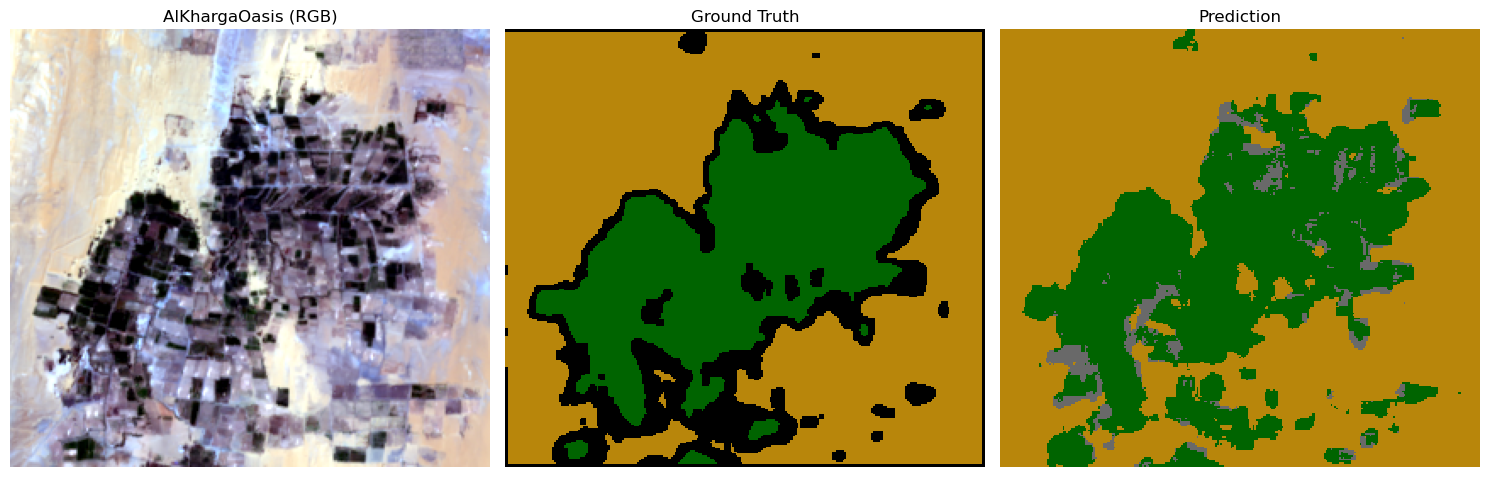

In [14]:
row = next(samples[samples["sample"].eq(TARGET_SAMPLE)].itertuples(index=False))
spectral, true = load_sample_rf(row)
pred = predict_scene_rf(model, spectral)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb_preview(spectral))
axes[0].set_title(f"{row.sample} (RGB)")

axes[1].imshow(colorize(true), interpolation="nearest")
axes[1].set_title("Ground Truth")

axes[2].imshow(colorize(pred), interpolation="nearest")
axes[2].set_title("Prediction")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
plt.show()


# Deep Learning U-Net Baseline

In [15]:
IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 20
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

MODEL_PATH = MODEL_DIR / "unet_baseline.pt"

def device_is_usable(device):
    layer = nn.Conv2d(12, 8, 3, padding=1).to(device)
    x = torch.randn(1, 12, 64, 64, device=device)
    with torch.no_grad():
        layer(x)

DEVICE = torch.device('cpu')
print("Using device:", DEVICE)

def load_sample_unet(row):
    with rio.open(row.spectral_path) as src:
        spectral = src.read().astype("float32")
    with rio.open(row.mask_path) as src:
        mask = clean_mask(src.read(1).astype("uint8"))
    return spectral, mask

def resize_scene(spectral, mask, size=IMAGE_SIZE):
    x = torch.from_numpy(spectral)
    y = torch.from_numpy(mask.astype(np.float32)).unsqueeze(0)

    x = F.interpolate(
        x.unsqueeze(0),
        size=(size, size),
        mode="bilinear",
        align_corners=False,
    ).squeeze(0)

    y = F.interpolate(
        y.unsqueeze(0),
        size=(size, size),
        mode="nearest",
    ).squeeze(0).squeeze(0).long()

    return x, y

def prepare_scene(spectral, mask, mean, std, size=IMAGE_SIZE):
    spectral = scale_input(spectral)
    raw_x, y = resize_scene(spectral, mask, size=size)
    x = (raw_x - mean[:, None, None]) / std[:, None, None]
    return x, y, raw_x

def compute_band_stats(frame):
    total = np.zeros(12, dtype=np.float64)
    total_sq = np.zeros(12, dtype=np.float64)
    pixel_count = 0

    for row in frame.itertuples(index=False):
        spectral, _ = load_sample_unet(row)
        spectral = scale_input(spectral).reshape(12, -1)

        total += spectral.sum(axis=1)
        total_sq += (spectral ** 2).sum(axis=1)
        pixel_count += spectral.shape[1]

    mean = total / pixel_count
    std = np.sqrt(np.clip(total_sq / pixel_count - mean ** 2, 1e-8, None))

    return torch.tensor(mean, dtype=torch.float32), torch.tensor(std, dtype=torch.float32)

def compute_class_weights(frame):
    counts = np.zeros(5, dtype=np.int64)

    for row in frame.itertuples(index=False):
        _, mask = load_sample_unet(row)
        counts += np.bincount(mask.reshape(-1), minlength=5)

    active_counts = np.maximum(counts[1:], 1)
    weights = np.zeros(5, dtype=np.float32)
    weights[1:] = active_counts.sum() / active_counts
    weights[1:] /= weights[1:].mean()

    return counts, torch.tensor(weights, dtype=torch.float32)

def mean_iou_from_confusion(cm):
    intersection = np.diag(cm)
    union = cm.sum(axis=1) + cm.sum(axis=0) - intersection
    return intersection / np.maximum(union, 1)

def predict_scene_unet(model, spectral, mask, mean, std):
    x, y, raw_x = prepare_scene(spectral, mask, mean, std)

    with torch.no_grad():
        logits = model(x.unsqueeze(0).to(DEVICE))

    pred = logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    return pred, y.numpy().astype(np.uint8), raw_x.numpy()

def evaluate_model_unet(model, frame, mean, std):
    cm = np.zeros((len(CLASS_IDS), len(CLASS_IDS)), dtype=np.int64)
    y_true, y_pred = [], []

    model.eval()

    for row in frame.itertuples(index=False):
        spectral, mask = load_sample_unet(row)
        pred, true, _ = predict_scene_unet(model, spectral, mask, mean, std)
        valid = true > 0

        cm += confusion_matrix(true[valid], pred[valid], labels=CLASS_IDS)
        y_true.append(true[valid].reshape(-1))
        y_pred.append(pred[valid].reshape(-1))

    iou = mean_iou_from_confusion(cm)
    metrics = pd.DataFrame({
        "class_id": CLASS_IDS,
        "class_name": TARGET_NAMES,
        "IoU": iou,
        "support": cm.sum(axis=1),
    })

    report = classification_report(
        np.concatenate(y_true),
        np.concatenate(y_pred),
        labels=CLASS_IDS,
        target_names=TARGET_NAMES,
        zero_division=0,
    )

    return metrics, report


Skipping cuda: GET was unable to find an engine to execute this computation
Using device: cpu


In [16]:
outer_split = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
samples = load_samples()
train_val_idx, test_idx = next(outer_split.split(samples, groups=samples["sample"]))

train_val_df = samples.iloc[train_val_idx].reset_index(drop=True)
test_df = samples.iloc[test_idx].reset_index(drop=True)

inner_split = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, val_idx = next(inner_split.split(train_val_df, groups=train_val_df["sample"]))

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

print(f"train scenes: {len(train_df)}")
print(train_df["sample"].tolist())
print()
print(f"val scenes: {len(val_df)}")
print(val_df["sample"].tolist())
print()
print(f"test scenes: {len(test_df)}")
print(test_df["sample"].tolist())


train scenes: 60
['AbuQurqas', 'AbuRawash', 'AbuZaabal', 'Akhmim', 'AlKhargaOasis', 'Alexandria', 'AswanHighDam', 'Balyana', 'Benha', 'Bibba', 'BirElAbd', 'BorgElArab', 'Dahab', 'Damietta', 'EastPortSaidPort', 'Edfu', 'ElAlamein', 'ElHammam', 'ElObourCity', 'ElShoroukCity', 'Farafra', 'FayoumCity', 'HawaraFayoum', 'HeliopolisCairo', 'IconicTower', 'Isna', 'KafrElSheikh', 'KomOmboSugarFactory', 'LakeBurullus', 'LakeManzala', 'LakeQarun', 'MaadiCairo', 'Maghagha', 'Mansoura', 'MarsaAlam', 'MarsaMatrouh', 'MarsaMatruhCoastalStrip', 'Matay', 'Minya', 'NagaaHammadiIndustrial', 'NasrCityCairo', 'NewAlamein', 'NorthSinaiAgriculturalArea', 'Nuweiba', 'QantaraEast', 'Qena', 'RashidRosetta', 'SadatCity', 'SaintCatherine', 'Samalut', 'SharqElOwainat', 'SohagEastBank', 'SuezPort', 'Taba', 'Tahta', 'TenthOfRamadanCity', 'WadiElGedidInterior', 'WadiElNatrun', 'WadiFeiran', 'Zagazig']

val scenes: 15
['AbuKabir', 'AinSokhna', 'Badari', 'BahariyaOasis', 'BenbanSolarPark', 'DakhlaOasis', 'Gerga', 'Karn

In [17]:
band_mean, band_std = compute_band_stats(train_df)
class_counts, class_weights = compute_class_weights(train_df)

print("band mean:")
display(pd.Series(band_mean.numpy()).rename("mean"))
print()
print("class counts:")
display(pd.DataFrame({
    "class_id": list(range(5)),
    "count": class_counts,
    "weight": class_weights.numpy(),
}))


band mean:


0     0.122529
1     0.147810
2     0.196826
3     0.240823
4     0.273478
5     0.299055
6     0.313304
7     0.319571
8     0.321028
9     0.324930
10    0.347250
11    0.307205
Name: mean, dtype: float32


class counts:


,class_id,count,weight
0,0,1311335,0.000000
1,1,562329,1.214847
2,2,1349285,0.506300
3,3,470764,1.451138
4,4,825337,0.827715


In [18]:
class SceneDataset(Dataset):
    def __init__(self, frame, mean, std, train=False, size=IMAGE_SIZE):
        self.frame = frame.reset_index(drop=True)
        self.mean = mean.clone()
        self.std = std.clone()
        self.train = train
        self.size = size

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        spectral, mask = load_sample_unet(row)
        x, y, _ = prepare_scene(spectral, mask, self.mean, self.std, size=self.size)

        if self.train and torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[2])
            y = torch.flip(y, dims=[1])

        if self.train and torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[1])
            y = torch.flip(y, dims=[0])

        return x, y


train_ds = SceneDataset(train_df, band_mean, band_std, train=True)
val_ds = SceneDataset(val_df, band_mean, band_std)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

len(train_ds), len(val_ds)


(60, 15)

In [19]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.pool(x))


class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        return self.conv(torch.cat([skip, x], dim=1))


class UNet(nn.Module):
    def __init__(self, in_ch=12, out_ch=5, base=32):
        super().__init__()
        self.inc = DoubleConv(in_ch, base)
        self.down1 = Down(base, base * 2)
        self.down2 = Down(base * 2, base * 4)
        self.down3 = Down(base * 4, base * 8)
        self.bottleneck = Down(base * 8, base * 16)
        self.up1 = Up(base * 16, base * 8, base * 8)
        self.up2 = Up(base * 8, base * 4, base * 4)
        self.up3 = Up(base * 4, base * 2, base * 2)
        self.up4 = Up(base * 2, base, base)
        self.outc = nn.Conv2d(base, out_ch, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.bottleneck(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        return self.outc(x)


model = UNet().to(DEVICE)


In [20]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE), ignore_index=0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    cm = np.zeros((len(CLASS_IDS), len(CLASS_IDS)), dtype=np.int64)

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(x)
            loss = criterion(logits, y)

            if train_mode:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)

        pred = logits.argmax(dim=1).detach().cpu().numpy()
        true = y.detach().cpu().numpy()
        valid = true > 0

        if valid.any():
            cm += confusion_matrix(true[valid], pred[valid], labels=CLASS_IDS)

    iou = mean_iou_from_confusion(cm)
    return total_loss / len(loader.dataset), float(iou.mean())


history = []
best_val_miou = -1.0

for epoch in tqdm(range(1, EPOCHS + 1), desc="Training"):
    train_loss, train_miou = run_epoch(train_loader, train_mode=True)
    val_loss, val_miou = run_epoch(val_loader, train_mode=False)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_miou": train_miou,
        "val_loss": val_loss,
        "val_miou": val_miou,
    })

    if val_miou > best_val_miou:
        best_val_miou = val_miou
        torch.save({
            "model_state": model.state_dict(),
            "band_mean": band_mean,
            "band_std": band_std,
            "history": history,
        }, MODEL_PATH)

history_df = pd.DataFrame(history)
history_df


Training:   0%|          | 0/20 [00:00<?, ?it/s]

,epoch,train_loss,train_miou,val_loss,val_miou
0,1,1.234730,0.462595,1.407679,0.604919
1,2,0.919836,0.681266,0.953101,0.607790
2,3,0.813367,0.698914,0.559744,0.889606
3,4,0.701853,0.779035,0.463952,0.942003
4,5,0.685103,0.763123,0.495070,0.818860
5,6,0.753832,0.703287,0.472253,0.909667
6,7,0.703415,0.736643,0.364705,0.898674
7,8,0.649945,0.746262,0.393211,0.890899
8,9,0.600553,0.790007,0.363079,0.930237
9,10,0.606913,0.753134,0.367164,0.954723


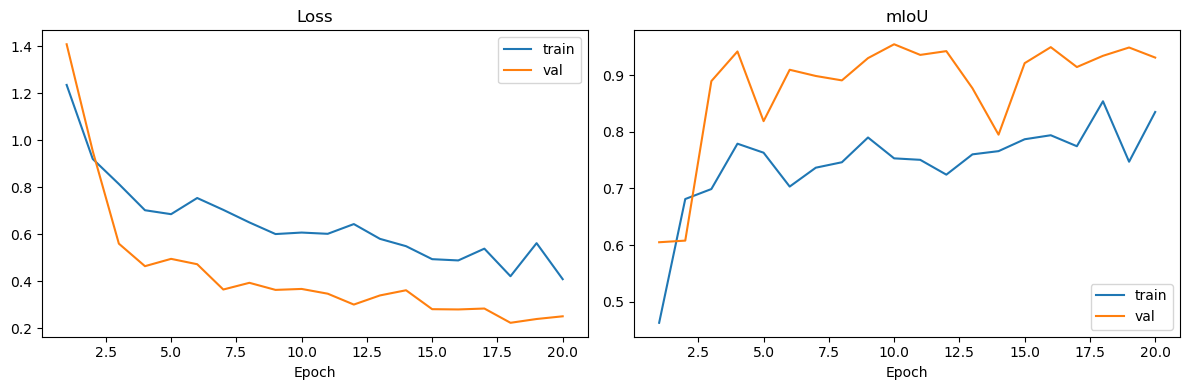

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_miou"], label="train")
axes[1].plot(history_df["epoch"], history_df["val_miou"], label="val")
axes[1].set_title("mIoU")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


In [22]:
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])

metrics, report = evaluate_model_unet(model, test_df, band_mean, band_std)

print(f"mIoU: {metrics['IoU'].mean():.3f}")
display(metrics.sort_values("class_id"))
print()
print("Classification report")
print(report)


mIoU: 0.940


,class_id,class_name,IoU,support
0,1,Greenery,0.914687,153542
1,2,Sand,0.946081,350035
2,3,Water,0.989455,200324
3,4,Cement,0.909518,311611



Classification report
              precision    recall  f1-score   support

    Greenery       0.95      0.97      0.96    153542
        Sand       0.99      0.96      0.97    350035
       Water       1.00      0.99      0.99    200324
      Cement       0.94      0.97      0.95    311611

    accuracy                           0.97   1015512
   macro avg       0.97      0.97      0.97   1015512
weighted avg       0.97      0.97      0.97   1015512



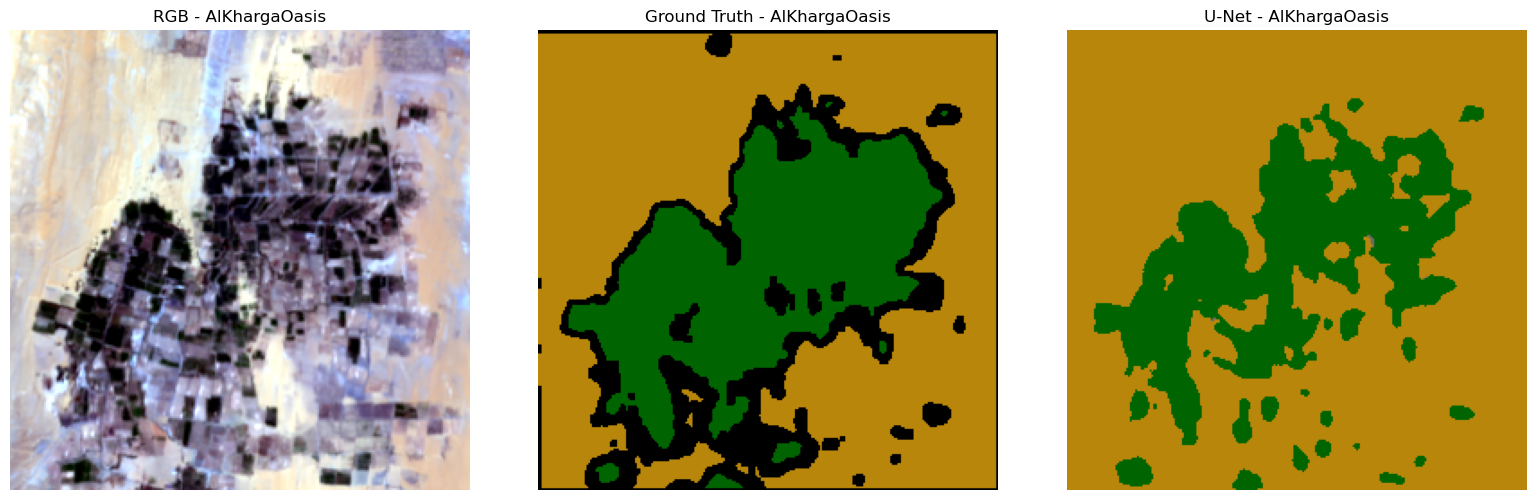

In [23]:
row = next(samples[samples["sample"].eq(TARGET_SAMPLE)].itertuples(index=False), None)
if row is None:
    raise ValueError(f"{TARGET_SAMPLE} not found in samples")

spectral, mask = load_sample_unet(row)
pred, true, raw = predict_scene_unet(model, spectral, mask, band_mean, band_std)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(rgb_preview(raw))
axes[0].set_title(f"RGB - {row.sample}")

axes[1].imshow(colorize(true))
axes[1].set_title(f"Ground Truth - {row.sample}")

axes[2].imshow(colorize(pred))
axes[2].set_title(f"U-Net - {row.sample}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [24]:
best_row = metrics.loc[metrics["IoU"].idxmax()]
worst_row = metrics.loc[metrics["IoU"].idxmin()]
best_epoch = history_df.loc[history_df["val_miou"].idxmax()]

print("Discussion")
print(
    f"U-Net used {len(train_df)} train scenes, {len(val_df)} val scenes and {len(test_df)} test scenes "
    f"for {EPOCHS} epochs at {IMAGE_SIZE}x{IMAGE_SIZE}."
)
print(
    f"Best val mIoU = {best_epoch['val_miou']:.3f} at epoch {int(best_epoch['epoch'])}, "
    f"and final test mIoU = {metrics['IoU'].mean():.3f}."
)
print(
    f"Best class: {best_row['class_name']} ({best_row['IoU']:.3f}). "
    f"Weakest class: {worst_row['class_name']} ({worst_row['IoU']:.3f})."
)
print(
    "This model captures spatial structure better, so large regions look cleaner, "
    "while class boundaries remain the main source of error."
)


Discussion
U-Net used 60 train scenes, 15 val scenes and 25 test scenes for 20 epochs at 256x256.
Best val mIoU = 0.955 at epoch 10, and final test mIoU = 0.940.
Best class: Water (0.989). Weakest class: Cement (0.910).
This model captures spatial structure better, so large regions look cleaner, while class boundaries remain the main source of error.
